<a href="https://colab.research.google.com/github/yeavil-neny/NLP-ProcesamientoLeguajeNatural/blob/main/Taller_2/Transformer_clasificacion_FA_v3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Desarrollo del taller 1**.

**Grupo:** Delta

**Integrantes:**
- Fredy Alvarez
- Anderson Pipicano
- Cristian Yepes
- Yenny Villarreal

### **Definición del Problema y Carga de Datos**

En este proyecto abordaremos la **clasificación de la satisfacción de clientes en plataformas de e-commerce** mediante técnicas de Procesamiento de Lenguaje Natural (NLP).

Las plataformas reciben miles de reseñas que, por su volumen, son difíciles de analizar manualmente. Por ello, se propone desarrollar un sistema que interprete automáticamente el sentimiento de cada reseña y lo clasifique en una escala de **1 a 5 estrellas**.

Para lograrlo, utilizaremos un modelo basado en redes LSTM, combinado con Embeddings, que permita capturar el contexto y la secuencia de las palabras.

Los datos provendrán del dataset **amazon_reviews_multi en español de Hugging Face**, compuesto por reseñas reales de compradores. Esto permitirá trabajar con desafíos propios del lenguaje natural, como errores ortográficos, expresiones informales y textos de diferentes longitudes.


In [ ]:
from datasets import load_dataset
import torch

# Verificamos GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Cargamos el dataset (Amazon Reviews en español por SetFit)
print("Descargando el dataset 'SetFit/amazon_reviews_multi_es'...")
dataset = load_dataset("SetFit/amazon_reviews_multi_es")

# Tomamos el subconjunto para entrenar rápido (¡mezclando los datos primero!)
subset_size_train = 50000
subset_size_eval = 5000

# Añadimos .shuffle(seed=42) antes de hacer el .select()
train_data = dataset['train'].shuffle(seed=42).select(range(subset_size_train))
val_data = dataset['validation'].shuffle(seed=42).select(range(subset_size_eval))
test_data = dataset['test'].shuffle(seed=42).select(range(subset_size_eval))

# Resumen y ejemplo
print(f"\n--- Resumen de Datos ---")
print(f"Train: {len(train_data)} | Val: {len(val_data)} | Test: {len(test_data)}")
print("\n--- Ejemplo de un registro ---")
print(f"Texto: {train_data[0]['text'][:250]}...")
print(f"Etiqueta (Estrellas): {train_data[0]['label']} (Escala de 0 a 4, donde 0 es 1 estrella)")

Descargando el dataset 'SetFit/amazon_reviews_multi_es'...


Repo card metadata block was not found. Setting CardData to empty.



--- Resumen de Datos ---
Train: 50000 | Val: 5000 | Test: 5000

--- Ejemplo de un registro ---
Texto: La montarlo se rompió una rueda debido a materiales débiles, pero al arreglarla funciona correctamente....
Etiqueta (Estrellas): 2 (Escala de 0 a 4, donde 0 es 1 estrella)


In [ ]:
train_data


Dataset({
    features: ['id', 'text', 'label', 'label_text'],
    num_rows: 50000
})

In [ ]:
val_data

Dataset({
    features: ['id', 'text', 'label', 'label_text'],
    num_rows: 5000
})

In [ ]:
test_data

Dataset({
    features: ['id', 'text', 'label', 'label_text'],
    num_rows: 5000
})

### **Análisis Exploratorio de Datos (EDA)**

In [ ]:
import pandas as pd

# Convertimos el dataset de Hugging Face a un DataFrame de Pandas
df_train = train_data.to_pandas()

# Mostramos las primeras 20 filas para explorar su estructura
df_train.tail(20)

,id,text,label,label_text
49980,es_0197991,"No lo he usado, se ve algo endeble pero lo que...",0,0
49981,es_0119839,POR EL PRECIO DE ESTOS DOS CATUCHOS ES IMPRESI...,3,3
49982,es_0318519,Regular estos dispositivos pecan de lo mismo.r...,2,2
49983,es_0236117,"Está bien, tampoco para tirar cohetes porque s...",2,2
49984,es_0984004,El kit está bien pero el pegamento es malísimo...,2,2
49985,es_0282933,Cuando llego nos parecio genial...muy comoda y...,0,0
49986,es_0496275,Hola yo la compré hace tiempo y me va muy bien...,2,2
49987,es_0303969,Satisfechos con el producto pero no con la ent...,4,4
49988,es_0413793,¿Alguien sabe donde se puede descargar las act...,2,2
49989,es_0267428,Todo ok y muy comoda,3,3


Al analizar las reseñas, se identifican algunas inconsistencias entre el contenido expresado por los usuarios y la calificación asignada. Por ejemplo, existen reseñas con una calificación de 3 cuyo contenido refleja un nivel de satisfacción que podría corresponder a la categoría 4. Del mismo modo, algunos usuarios manifiestan que su experiencia fue excelente, pero seleccionan una categoría inmediatamente inferior a la máxima.

Estas discrepancias pueden introducir ruido en las etiquetas utilizadas para entrenar el modelo y dificultar la diferenciación entre clases cercanas. En consecuencia, el modelo podría presentar mayor confusión al clasificar reseñas pertenecientes a categorías adyacentes, como 3 y 4.

A partir de este comportamiento, se espera que las clases extremas (0 y 4) presenten una mayor precisión en las predicciones del modelo LSTM, debido a que, en principio, deberían representar sentimientos más claramente diferenciados. Por el contrario, las clases intermedias podrían presentar un mayor nivel de confusión como consecuencia de la subjetividad de las calificaciones y de las inconsistencias observadas entre el texto de las reseñas y las etiquetas asignadas.

/tmp/ipykernel_6072/727094088.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_train, x='label', palette='viridis')


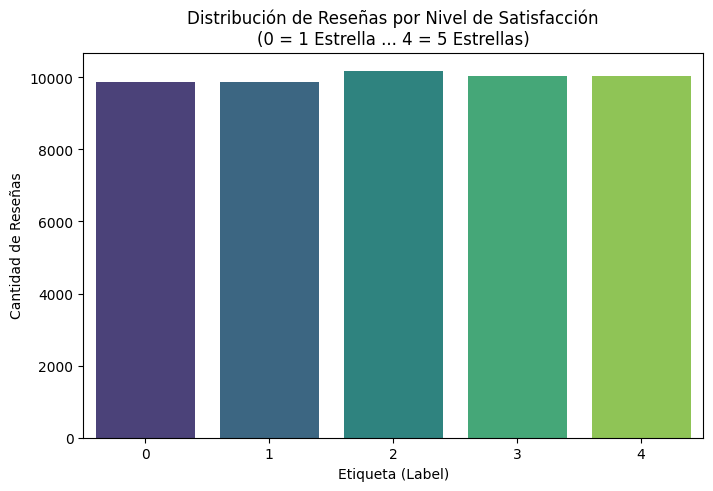

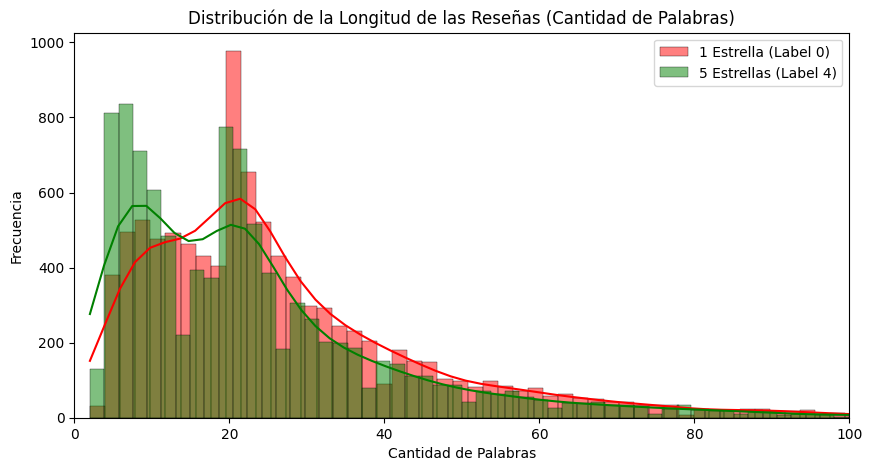

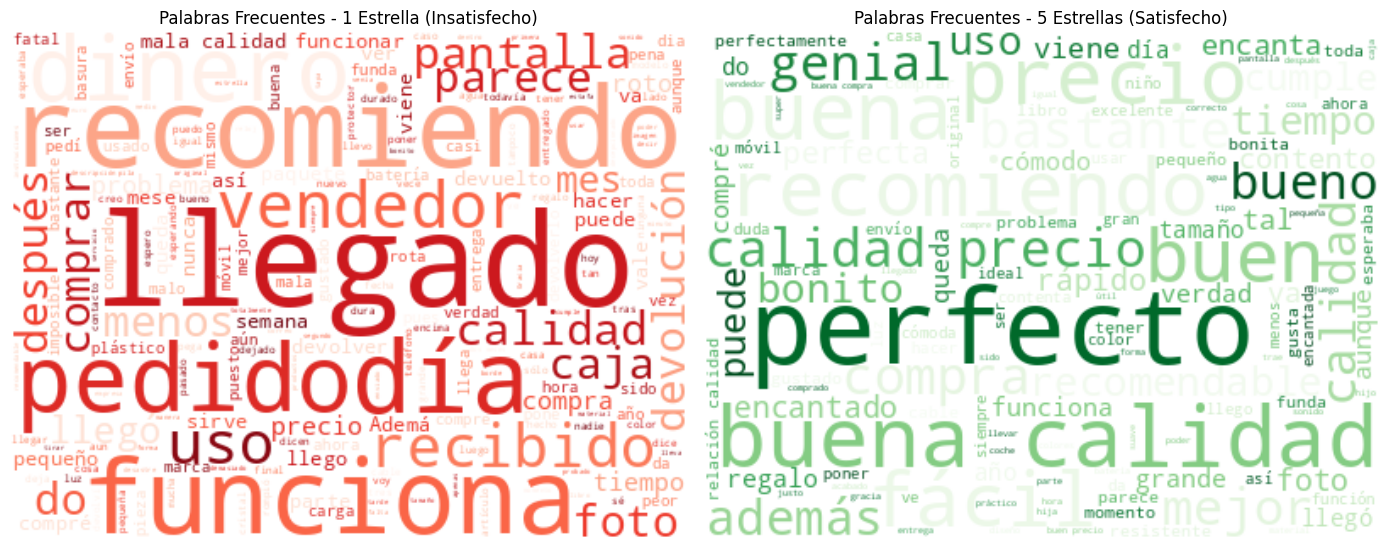

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import nltk
from nltk.corpus import stopwords

# Descargamos las palabras vacías (stopwords) en español para limpiar las nubes de palabras
nltk.download('stopwords', quiet=True)
stop_words_sp = set(stopwords.words('spanish'))
# Añadimos algunas palabras comunes que no aportan sentimiento
stop_words_sp.update(['producto', 'amazon', 'bien', 'mal', 'hace', 'solo', 'si', 'mas', 'q', 'que'])

# 1. Convertimos el dataset de Hugging Face a un DataFrame de Pandas
df_train = train_data.to_pandas()

# Calculamos la longitud de cada reseña (cantidad de palabras)
df_train['word_count'] = df_train['text'].apply(lambda x: len(str(x).split()))

# --- GRÁFICO 1: Distribución de Clases ---
plt.figure(figsize=(8, 5))
sns.countplot(data=df_train, x='label', palette='viridis')
plt.title('Distribución de Reseñas por Nivel de Satisfacción\n(0 = 1 Estrella ... 4 = 5 Estrellas)')
plt.xlabel('Etiqueta (Label)')
plt.ylabel('Cantidad de Reseñas')
plt.show()

# --- GRÁFICO 2: Longitud de Textos (Extremos) ---
plt.figure(figsize=(10, 5))
sns.histplot(data=df_train[df_train['label'] == 0], x='word_count', color='red', label='1 Estrella (Label 0)', kde=True, alpha=0.5)
sns.histplot(data=df_train[df_train['label'] == 4], x='word_count', color='green', label='5 Estrellas (Label 4)', kde=True, alpha=0.5)
plt.title('Distribución de la Longitud de las Reseñas (Cantidad de Palabras)')
plt.xlabel('Cantidad de Palabras')
plt.ylabel('Frecuencia')
plt.legend()
plt.xlim(0, 100) # Limitamos a 100 palabras para enfocar el cuerpo principal
plt.show()

# --- GRÁFICO 3: Nubes de Palabras ---
text_negativo = " ".join(df_train[df_train['label'] == 0]['text'].tolist())
text_positivo = " ".join(df_train[df_train['label'] == 4]['text'].tolist())

# Generamos las nubes
wc_neg = WordCloud(stopwords=stop_words_sp, background_color='white', colormap='Reds', width=400, height=300).generate(text_negativo)
wc_pos = WordCloud(stopwords=stop_words_sp, background_color='white', colormap='Greens', width=400, height=300).generate(text_positivo)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].imshow(wc_neg, interpolation='bilinear')
axes[0].set_title('Palabras Frecuentes - 1 Estrella (Insatisfecho)')
axes[0].axis('off')

axes[1].imshow(wc_pos, interpolation='bilinear')
axes[1].set_title('Palabras Frecuentes - 5 Estrellas (Satisfecho)')
axes[1].axis('off')
plt.tight_layout()
plt.show()

La grafica de barras muestran que hay una cantidad muy similar de reseñas para 1, 2, 3, 4 y 5 estrellas (rondando las 10000 reseñas por clase). Lo que indica que las clases se encuentran balanceadas reduciendo el riego de sesgo durante el entrenamiento de los modelos.

La grafica de frecuencia nos muestra que fijar una longitud máxima de secuencia (max_length) alrededor de 50 a 100 tokens será más que suficiente para capturar el mensaje completo del cliente sin desperdiciar memoria computacional.

Existe una separación semántica evidente entre los dos extremos de satisfacción. En la nube de 1 estrella, predominan palabras de fallo, frustración o tiempo (ej. roto, devolver, dinero, llegó, malo, nunca). En la nube de 5 estrellas, destacan palabras de exaltación y valor (ej. perfecto, calidad, precio, recomiendo, encanta, excelente).

In [ ]:
# Iteramos por cada una de las 5 categorías (de 0 a 4)
for estrella in range(5):
    print(f"{"="*50}")
    print(f"CATEGORÍA {estrella} ({estrella + 1} Estrellas)")
    print(f"{"="*50}")

    # Filtramos el DataFrame por la etiqueta actual y tomamos los primeros 2 registros
    ejemplos = df_train[df_train['label'] == estrella].head(2)

    for idx, row in ejemplos.iterrows():
        print(f" {row['text']}\n")

CATEGORÍA 0 (1 Estrellas)
 Tiene 6 meses y ya se ha roto una goma

 35 eur tirados a la basura, no me ha servido, me quedé sin batería y no me la cargó

CATEGORÍA 1 (2 Estrellas)
 El servicio ha sido muy bueno, me ha llegado 2 días antes de lo previsto. En cuanto al producto no es que me haya dado muy buenas primeras impresiones. El borde del protector es de plástico y lo único que hay de cristal es la pantalla. Además el plástico es muy fino. A nivel estético queda muy bien y se ajusta perfectamente, la única queja que tengo es eso, que no sea todo de cristal y que para mi gusto es demasiado fino. De la resistencia no tengo ni idea ya que es el primer día que lo llevo. No creo que sea mal producto del todo si no que depende del gusto y el cuidado que tenga cada uno de su móvil. Personalmente creo que por el mismo precio hay otros productos que si que son enteros de cristal y más gordos que por lo menos a mí me generan más confianza.

 Queda muy feo con el borde metalico ademas tapa la

Al analizar los textos, se observa que los extremos de satisfacción utilizan un lenguaje directo que facilitará el aprendizaje del modelo. Las reseñas de una estrella se centran en quejas puntuales sobre pérdida de dinero o fallas físicas del producto, mientras que las de cinco estrellas validan la compra con adjetivos positivos directos ("genial", "perfecto"). Esta separación semántica permitirá que los embeddings clasifiquen los casos positivos y negativos con menor margen de error.

Por otro lado, el principal reto para la red neuronal se encuentra en las categorías intermedias, donde el lenguaje es mixto y con múltiples matices. En estos niveles, los usuarios emplean conectores como "pero" o "aunque" para contrastar aspectos positivos del servicio con detalles negativos del producto en una misma oración. En estos casos de satisfacción parcial, la arquitectura LSTM resulta clave: en lugar de contar palabras aisladas, procesará el contexto secuencial completo de la frase para asignar la clasificación correcta.

### **Preprocesamiento, Tokenización y DataLoaders**

Las redes neuronales no entienden texto en bruto. En esta fase transformaremos nuestras reseñas en tensores numéricos consumibles por PyTorch. El proceso consta de:
1. **Tokenización:** Limpiar el texto y dividirlo en palabras.
2. **Vocabulario:** Crear un diccionario que asigne un ID numérico único a las 20,000 palabras más frecuentes.
3. **Padding:** Estandarizar la longitud de todas las oraciones a 100 tokens (como vimos en el EDA, la mayoría de reseñas son cortas).
4. **DataLoaders:** Empaquetar los datos en lotes (*batches*) para inyectarlos a la tarjeta gráfica durante el entrenamiento.

In [ ]:
# Calcular la longitud en caracteres de las reseñas
text_lengths = [len(row['text']) for row in train_data]

print(f"Texto más corto (caracteres): {min(text_lengths)}")
print(f"Texto más largo (caracteres): {max(text_lengths)}")
print(f"Longitud promedio (caracteres): {sum(text_lengths) / len(text_lengths):.2f}")

Texto más corto (caracteres): 17
Texto más largo (caracteres): 2132
Longitud promedio (caracteres): 151.30


La función simple_tokenizer toma el texto crudo, lo pasa a minúsculas y elimina caracteres raros. Sin embargo, a diferencia de otros modelos, aquí le ordenamos explícitamente que no borre los signos de exclamación (!). En el análisis de sentimiento, un "!" aporta muchísima información emocional, por lo que separar la frase en palabras conservando este símbolo es clave.

El código lee todas las reseñas de entrenamiento y cuenta cuáles son las 20,000 palabras más repetidas. A cada una le asigna un número entero único (su ID). Además, crea dos identificadores especiales:

[PAD] (ID 0): Un espacio en blanco de "relleno".

[UNK] (ID 1): Significa Unknown (Desconocido). Se usará si en el futuro un cliente escribe una palabra rarísima que no está en nuestro top 20,000.

La función tokenize_text toma la frase ya separada y busca cada palabra en el diccionario para convertirla en su número ID.
Como las redes neuronales exigen que todas las entradas tengan exactamente el mismo tamaño, usamos el Padding: si una reseña solo tiene 5 palabras (5 números), el código rellena los 95 espacios restantes con el número 0 ([PAD]) hasta que la lista mida exactamente 100 números.

La memoria de la computadora explotaría si intentamos enseñarle al modelo las 50,000 reseñas de entrenamiento al mismo tiempo.  

La clase AmazonReviewsDataset toma las listas de números y las convierte en Tensores (matrices matemáticas optimizadas de PyTorch).  

El DataLoader toma todos esos tensores y los divide en "Lotes" (batches). Con un tamaño de lote de 32, se crean 1,563 lotes de reseñas en total. El modelo procesará 32 reseñas, ajustará su aprendizaje, y luego tomará las siguientes 32 de forma iterativa.

Repo card metadata block was not found. Setting CardData to empty.


Vocabulario de 5000 palabras -> Cobertura del corpus: 94.21%
Vocabulario de 10000 palabras -> Cobertura del corpus: 97.18%
Vocabulario de 20000 palabras -> Cobertura del corpus: 99.07%
Vocabulario de 30000 palabras -> Cobertura del corpus: 99.79%
Vocabulario de 50000 palabras -> Cobertura del corpus: 100.00%


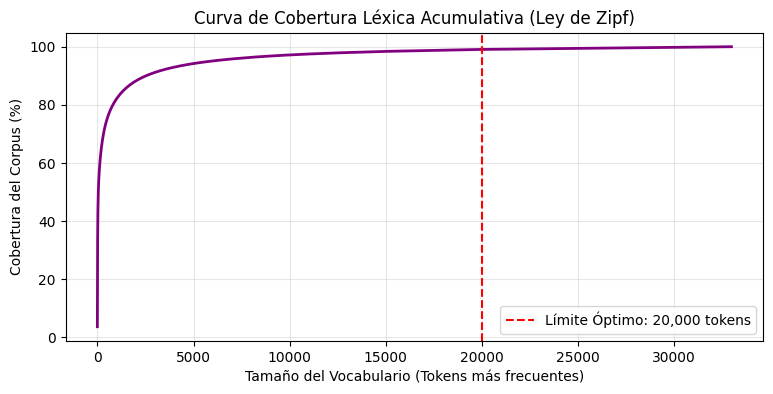

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
import re
from datasets import load_dataset

# --- Replicar la preparación de datos necesaria para esta celda ---
# Cargar el dataset
dataset = load_dataset("SetFit/amazon_reviews_multi_es")

# Tomar el subconjunto para entrenar
subset_size_train = 50000
train_data = dataset['train'].shuffle(seed=42).select(range(subset_size_train))

# Definir el tokenizer
def simple_tokenizer(text: str):
    text = text.lower() #Convierte todo el texto a minúsculas para estandarizar
    text = re.sub(r'([!¡])', r' \1 ', text) #separa los signos de exclamación (¡ y !) añadiendo un espacio antes y después. Esto evita que '¡hola!' se tome como una sola palabra y permite que '¡' y '!' sean tokens independientes.
    text = re.sub(r'[^a-záéíóúüñ0-9!¡]+', ' ', text) # Elimina signos de puntuación (excepto ! e ¡), números y caracteres especiales (como ,, ., !, ?, @),, cambiándolos por espacios. Tambien, se incluyen '!' y '¡' dentro de los corchetes [^...] para que NO sean borrados.
    return text.strip().split() # Quita espacios innecesarios al inicio/final y divide el texto por espacios, devolviendo la lista limpia de palabras y signos de exclamación.

# Construir el vocabulario sobre train_data y contar tokens
token_counts = Counter() #Resultado: Counter({'hola': 3, 'mundo': 1, 'python': 1})
for text in train_data['text']:
    token_counts.update(simple_tokenizer(text))

#Tamaño de vocabulario segun tokens mas frecuentes (se sustenta en grafica de Curva de Cobertura Léxica Acumulativa)
#Top 20,000 tokens reservando espacio para [PAD]=0 y [UNK]=1
#top_n_tokens = list(token_counts.keys())[:20000 - 2] #Solo extrae las primeras 19,998 llaves tal y como están guardadas en el diccionario. Si el diccionario no fue previamente ordenado por frecuencia, tomará las palabras en el orden en que aparecieron por primera vez en el texto (orden de inserción), ignorando cuáles son realmente las más comunes.
max_vocab = 20000
top_tokens = [token for token, _ in token_counts.most_common(max_vocab - 2)] # Asegurar que tomamos los tokens MÁS FRECUENTES

vocab = {'[PAD]': 0, '[UNK]': 1}
for token in top_tokens:
    vocab[token] = len(vocab)
# --- Fin de la replicación de preparación de datos ---

# Calcular la frecuencia acumulativa del vocabulario
total_tokens_count = sum(token_counts.values())
sorted_frequencies = sorted([freq for token, freq in token_counts.most_common()], reverse=True)
cumulative_frequencies = np.cumsum(sorted_frequencies) / total_tokens_count

# Puntos de corte a evaluar
vocab_sizes = [5000, 10000, 20000, 30000, 50000]
coverages = [cumulative_frequencies[min(v, len(cumulative_frequencies)-1)] * 100 for v in vocab_sizes]

for v, cov in zip(vocab_sizes, coverages):
    print(f"Vocabulario de {v} palabras -> Cobertura del corpus: {cov:.2f}%")

# Gráfica de Cobertura Acumulativa
plt.figure(figsize=(9, 4))
plt.plot(cumulative_frequencies[:40000] * 100, color='purple', lw=2)
plt.axvline(x=20000, color='red', linestyle='--', label='Límite Óptimo: 20,000 tokens')
plt.title('Curva de Cobertura Léxica Acumulativa (Ley de Zipf)')
plt.xlabel('Tamaño del Vocabulario (Tokens más frecuentes)')
plt.ylabel('Cobertura del Corpus (%)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


La **Curva de Cobertura Léxica Acumulativa** (inspirada en la **Ley de Zipf** sobre la distribución de la frecuencia de las palabras en el lenguaje natural) obtenida en la gráfica anterior, nos permite justificar la elección de un tamaño de vocabulario de 20,000 tokens.

Como se observa en la visualización, un vocabulario de 20,000 palabras es capaz de capturar aproximadamente el **99.07% de la cobertura del corpus** de reseñas. Este punto representa un equilibrio óptimo: al incluir más palabras (por ejemplo, 30,000 o 50,000), la ganancia en cobertura léxica es marginal (99.79% y 100% respectivamente), mientras que el costo computacional y la complejidad del modelo aumentarían significativamente al procesar y almacenar un vocabulario más grande con muchas palabras de baja frecuencia y poco valor informativo. Por otro lado, un vocabulario más pequeño (5,000 o 10,000 palabras) dejaría una porción considerable del corpus como '[UNK]' (desconocida), perdiendo valiosa información semántica.

Esta decisión se alinea con los principios de la Ley de Zipf, que postula que unas pocas palabras son muy frecuentes, mientras que la mayoría son raras. Al truncar el vocabulario en 20,000 palabras, nos aseguramos de incluir las palabras más informativas y frecuentes, dejando fuera las 'colas largas' de palabras poco comunes que rara vez aparecen, pero que dispararían el tamaño del vocabulario.

Para profundizar en la Ley de Zipf y su aplicación, se puede consultar el artículo: "Ley de frecuencia de palabras de Zipf en el lenguaje natural: una revisión crítica y perspectivas futuras.": https://pmc.ncbi.nlm.nih.gov/articles/PMC4176592/


In [ ]:
# Analizando el valor de max_length a partir de la grafica con la distribución de las longitudes de las reseñas que mide "Cantidad de palabras Vs Frecuencia" (Mayoria entre 50 y 60)
"""
Desperdicio de recursos: Si se fija max_length=100,128 o cualquier valor superior de 50 a 60, se obliga al modelo a procesar entre un 40% y un 80% de tokens de relleno ([PAD]) en casi todos
los datos del dataset. Esto aumentará innecesariamente el consumo de memoria VRAM y el tiempo de entrenamiento sin aportar información útil.
"""

# Calcula el percentil 95 y 98 usando train_data
longitudes = [len(simple_tokenizer(record['text'])) for record in train_data]

print("Percentil 95:", np.percentile(longitudes, 95))
print("Percentil 98:", np.percentile(longitudes, 98))

Percentil 95: 72.0
Percentil 98: 99.0


Analizando el valor de max_length a partir de la grafica con la distribución de las longitudes de las reseñas que mide "Cantidad de palabras Vs Frecuencia" (Mayoria entre 50 y 60)

Desperdicio de recursos: Si se fija max_length=100,128 o cualquier valor superior de 50 a 60, se obliga al modelo a procesar entre un 40% y un 80% de tokens de relleno ([PAD]) en casi todos
los datos del dataset. Esto aumentará innecesariamente el consumo de memoria VRAM y el tiempo de entrenamiento sin aportar información útil.

In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader
from collections import Counter
import re

def simple_tokenizer(text: str):
    text = text.lower()
    # Separamos los signos de exclamación dejándoles un espacio a los lados para que no se peguen a las palabras
    text = re.sub(r'([!¡])', r' \1 ', text)
    # Luego limpiamos lo demás
    text = re.sub(r'[^a-záéíóúüñ0-9!¡]+', ' ', text)
    return text.strip().split()

# 2. Construir el vocabulario basado SOLO en el conjunto de entrenamiento
print("Construyendo vocabulario...")
token_counts = Counter()
for text in train_data['text']:
    token_counts.update(simple_tokenizer(text))

max_vocab = 20000
top_tokens = [token for token, _ in token_counts.most_common(max_vocab - 2)]

# Guardamos espacio para los tokens especiales
vocab = {'[PAD]': 0, '[UNK]': 1}
for token in top_tokens:
    vocab[token] = len(vocab)

print(f"Tamaño del vocabulario: {len(vocab)} tokens")

# 3. Función para convertir texto a lista de IDs (con padding)
def tokenize_text(text: str, max_length: int = 75):
    # max_length de 100 es ideal según vimos en nuestra gráfica de longitud
    token_ids = [vocab.get(token, vocab['[UNK]']) for token in simple_tokenizer(text)[:max_length]]
    # Añadimos ceros (Padding) para que todas las secuencias midan exactamente 100
    token_ids += [vocab['[PAD]']] * (max_length - len(token_ids))
    return token_ids

# Prueba rápida para ver qué hace el código
print("\nEjemplo de texto:", "¡Este producto es terrible!")
print("Tokenizado en IDs:", tokenize_text("¡Este producto es terrible!", max_length=15))

# 4. Crear la clase Dataset y los DataLoaders de PyTorch
class AmazonReviewsDataset(Dataset):
    def __init__(self, dataset, tokenizer_fn, max_length=75):
        self.dataset = dataset
        self.tokenizer_fn = tokenizer_fn
        self.max_length = max_length

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        row = self.dataset[idx]
        input_ids = torch.tensor(self.tokenizer_fn(row['text'], self.max_length), dtype=torch.long)
        # Longitud real = cantidad de tokens antes de llegar al padding, con mínimo de 1
        length = int((input_ids != 0).sum().item())
        length = max(length, 1)
        label = torch.tensor(row['label'], dtype=torch.long)
        return {'input_ids': input_ids, 'length': length, 'label': label}

# Define el campo de visión fijo del modelo para cada reseña.
seq_length = 75
batch_size = 32 if torch.cuda.is_available() else 16

print("\nEmpaquetando en DataLoaders...")
train_dataset_pt = AmazonReviewsDataset(train_data, tokenize_text, seq_length)
val_dataset_pt = AmazonReviewsDataset(val_data, tokenize_text, seq_length)
test_dataset_pt = AmazonReviewsDataset(test_data, tokenize_text, seq_length)

train_loader = DataLoader(train_dataset_pt, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset_pt, batch_size=batch_size)
test_loader = DataLoader(test_dataset_pt, batch_size=batch_size)

print(f"¡DataLoaders listos! Lotes de entrenamiento creados: {len(train_loader)}")

Construyendo vocabulario...
Tamaño del vocabulario: 20000 tokens

Ejemplo de texto: ¡Este producto es terrible!
Tokenizado en IDs: [911, 52, 32, 8, 3699, 42, 0, 0, 0, 0, 0, 0, 0, 0, 0]

Empaquetando en DataLoaders...
¡DataLoaders listos! Lotes de entrenamiento creados: 1563


Se identifico un problema con el padding, este radica en que las reseñas cortas se rellenan con ceros ([PAD]) para alcanzar la longitud fija de 100 tokens, lo que podría provocar que la red neuronal malgaste capacidad computacional procesando espacios vacíos sin contenido semántico. Este inconveniente se resolvió en el cuaderno aplicando dos estrategias clave: la configuración de padding_idx=0 en la capa de embeddings para que PyTorch ignore y desactive la actualización de gradientes en dichos ceros, y el uso de la función pack_padded_sequence en el bloque LSTM, la cual le indica estrictamente a la red dónde finaliza cada reseña real para suspender de forma matemática las operaciones recurrentes sobre el relleno.

Cuando se utiliza padding sin excluir formalmente los ceros, el modelo comete el error de procesar los espacios vacíos como si tuvieran un significado real. Esto distorsiona las activaciones internas de la celda recurrente, provocando que la red se sature de información irrelevante y no logre identificar los patrones que diferencian las categorías de satisfacción.


# **Modelo Transformer transformers-from-scratch**

In [ ]:
# Instalar PyTorch Lightning y TorchMetrics (ejecutar si no están instalados)
!pip install pytorch-lightning torchmetrics -q

import torch
import torch.nn as nn
import torch.nn.functional as F
import math
import pytorch_lightning as pl
from torchmetrics import Accuracy
from pytorch_lightning import Trainer
from pytorch_lightning.callbacks.early_stopping import EarlyStopping
from enum import Enum
# Reemplaza la línea de importación de torchmetrics en la Celda 12 con esta:
from torchmetrics import Accuracy, Precision, Recall, F1Score

**SinusoidPE y LearnablePE:** Son dos estrategias para inyectar el orden de las palabras. SinusoidPE usa la fórmula matemática original de senos y cosenos estáticos (del paper Attention Is All You Need), mientras que LearnablePE deja que la red aprenda por su cuenta cómo representar las posiciones.


**okenAndPosEmbedding:** Es el bloque integrador. Toma la palabra, busca su significado (Token Embedding) y le suma su ubicación (Positional Embedding). Este vector combinado es la entrada real que recibirán los bloques

In [ ]:
class PosEncodingType(Enum):
    SINUSOID = 1
    LEARNABLE = 2

class SinusoidPE(nn.Module):
    """Positional Encoding sinusoidal, tal como lo define el paper.

    Se pre-calcula una sola vez (no tiene parámetros entrenables) y se suma a
    los embeddings de tokens: las dimensiones pares llevan seno y las impares
    coseno de la posición escalada por 10000^(2i/d_model).

    """
    def __init__(self, max_len: int, d_model: int):
        super(SinusoidPE, self).__init__()
        # Definimos un vector columna con las posiciones de la secuencia de entrada (pos)
        pos = torch.arange(max_len).unsqueeze(1)
        # Definimos un vector de fila con las dimensiones del embedding (i)
        i = torch.arange(d_model).unsqueeze(0)

        # Calculamos el denominador segun la formula
        div_term = 1 / torch.pow(10000, (2 * (i // 2)) / torch.tensor(d_model, dtype=torch.float32))
        # Aplicamos el denominador a las posiciones
        angle_rads = pos * div_term

        # Inicializamos la matriz de positional encodings
        pos_encoding = torch.zeros(max_len, d_model)
        # Calculamos los embeddings para los numeros pares con seno: PE(pos, 2i)
        pos_encoding[:, 0::2] = torch.sin(angle_rads[:, 0::2])
        # Calculamos los embdeddings para los numeros inpares con coseno: PE(pos, 2i+1)
        pos_encoding[:, 1::2] = torch.cos(angle_rads[:, 1::2])

        # Registramos la variable como atributo de clase
        self.register_buffer("pos_encoding", pos_encoding.unsqueeze(0), persistent=False)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # Sumamos el PE precalculado, truncado a la longitud real de la secuencia
        return x + self.pos_encoding[:, :x.size(1), :]

class LearnablePE(nn.Module):
    """Variante alternativa: PE aprendido.

    En lugar de pre-calcular seno/coseno, una tabla nn.Embedding aprende un
    vector por posición durante el entrenamiento (el enfoque que usan BERT/GPT).
    """

    def __init__(self, vocab_size: int, d_model: int, max_len: int = float('-inf')):
        super(LearnablePE, self).__init__()
        self.max_len = max_len
        self.embedding = nn.Embedding(vocab_size, d_model)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        positions = torch.arange(0, max(x.size(-1), self.max_len)).to(x.device)
        return x + self.embedding(positions)

class TokenAndPosEmbedding(nn.Module):
    def __init__(self, max_len: int, embed_dim: int, vocab_size: int, pos_encoding_type: PosEncodingType = PosEncodingType.SINUSOID):
        super(TokenAndPosEmbedding, self).__init__()
        self.token_emb = nn.Embedding(num_embeddings=vocab_size, embedding_dim=embed_dim)
        if pos_encoding_type == PosEncodingType.SINUSOID:
            self.pos_emb = SinusoidPE(max_len, embed_dim)
        else:
            self.pos_emb = LearnablePE(vocab_size, embed_dim)

    def forward(self, x):
        # 1) Embedding denso de cada token id
        token_emb = self.token_emb(x)
        # 2) Le sumamos el encoding posicional
        return self.pos_emb(token_emb)

**MultiHeadAttention:** Es el motor que permite al modelo leer toda la reseña al mismo tiempo y descubrir las relaciones directas entre las palabras, sin importar qué tan lejos estén en la oración. Al usar múltiples "cabezas" (num_heads), el modelo puede analizar diferentes aspectos semánticos simultáneamente (ej. una cabeza rastrea a quién va dirigido el adjetivo, mientras otra busca palabras de negación como "no" o "nunca"). También contiene la función _scaled_dot_product, que se encarga de aplicar la máscara para ocultar los tokens de relleno ([PAD]) y obligar a la red a ignorarlos completamente.


**TransformerBlock**: Es la estructura organizativa de una capa del modelo. Toma el resultado de la atención y lo estabiliza usando Normalización por Capas (LayerNorm). Luego, lo pasa por la subred Feed-Forward (ffn) (la de 1024 dimensiones que analizamos antes) para procesar el significado profundo. Crucialmente, implementa conexiones residuales (los signos de suma en x + attn_output), que son "atajos" que permiten sumar la información original a los nuevos cálculos para que los datos no se degraden a medida que el modelo se hace más profundo.

In [ ]:
class MultiHeadAttention(nn.Module):
    def __init__(self, embed_size: int, num_heads: int = 8):
        super(MultiHeadAttention, self).__init__()
        self.embed_size = embed_size
        self.num_heads = num_heads
        # OJO: usa el operador bit a bit '&' en lugar de '%'. Con estos tamaños
        # (128/256 y 8) el resultado es 0 y pasa, pero lo semánticamente correcto
        # sería '%' para exigir divisibilidad exacta.
        assert embed_size & num_heads == 0, 'El tamaño del embedding debería ser divisible por el numero de cabezas'
        self.projection_dim = embed_size // num_heads
        # Proyecciones Q, K, V: capas lineales que transforman cada token en
        # su vector de query, key y value. Nótese que usan la variable global
        # 'emb_dim' y no el parámetro 'embed_size' (detalle del ejemplo original).
        self.query = nn.Linear(embed_size, embed_size)
        self.key = nn.Linear(embed_size, embed_size)
        self.value = nn.Linear(embed_size, embed_size)
        # (typo heredado del ejemplo: 'comibe_heads' debería ser 'combine_heads')
        # Capa final que mezcla las cabezas concatenadas de vuelta a emb_dim.
        self.combine_heads = nn.Linear(embed_size, embed_size)

    def _scaled_dot_product(self, q, k, v, mask=None):
        """scaled dot product.

        Esta función define el bloque mencionado.
        Aquí se hace la multiplicación de matrices
        entre los Q, K y V para luego calcular el
        score de atención.

        Nótese además que aquí aplicamos una máscara
        de atención. Esto se debe a que como estamos
        rellenando las cadenas cortas con un token que
        en si mismo no trae ningún significado, no queremos
        que la red desperdicie recursos operando sobre este
        token, entonces usamos la máscara para poner los valores
        de atención en numeros muy pequeños para que al
        calcular el score, estos no sobresalgan sobre los demás.
        """
        # d_k para el escalamiento
        d_k = q.size()[-1]
        # multiplicacion Q \cdot K^T y escalamiento
        attn_logits = torch.matmul(q, k.transpose(-2, -1)) / math.sqrt(d_k)

        # Se aplica la máscara
        if mask is not None:
            # Adaptamos la máscara para que coincida con las dimensiones de las cabezas
            attn_logits = attn_logits.masked_fill(mask.unsqueeze(1).unsqueeze(2) == 0, -9e15)

        # Se calcula el score de atención.
        attention = torch.softmax(attn_logits, dim=-1)
        # Se obtienen los valores tras el score de atención.
        values = torch.matmul(attention, v)
        return values, attention

    def _separate_heads(self, x, batch_size):
        # Llega: (batch, seq_len, emb_dim)
        x = x.reshape(batch_size, -1, self.num_heads, self.projection_dim) # (batch, seq_len, num_heads, emb_dim / num_heads)
        return x.permute(0, 2, 1, 3) # (batch, num_heads, seq_len, emb_dim / num_heads)

    def forward(self, x, mask=None):
        """forward

        Este es todo el forward pass del multi-head attention.
        Aquí se coordina el resto de las operaciones, como
        la concatenación de las múltiples cabezas como
        el paso por la capa densa previo a entregar el
        resultado.
        """
        # x: (batch, seq_len, emb_dim)
        batch_size, seq_len, emb_dim = x.size()

        # 1) Proyectamos la entrada a las tres representaciones: Query, Key, Value y # 2) Partimos cada proyección en 'num_heads' cabezas más pequeñas
        q = self._separate_heads(self.query(x), batch_size)
        k = self._separate_heads(self.key(x), batch_size)
        v = self._separate_heads(self.value(x), batch_size)

        # 3) Atención escalada por cabeza (aplicando la máscara de padding)
        weights, attention = self._scaled_dot_product(q, k, v, mask)

        # 4) Reordenamos y concatenamos las cabezas de vuelta a emb_dim # (0, 2, 1, 3) -> (batch, seq_len, num_heads, emb_dim / num_heads)
        weights = weights.permute(0, 2, 1, 3).reshape(batch_size, seq_len, emb_dim)
        # 5) Mezcla final de las cabezas concatenadas
        output = self.combine_heads(weights)
        return output

class TransformerBlock(nn.Module):
    """Bloque encoder del Transformer.

    Combina atención multi-cabeza y una red feed-forward, cada una seguida de
    LayerNorm. Nota: a diferencia del paper original, aquí NO se usan conexiones
    residuales (x + subcapa); se normaliza la salida de cada subcapa.
    """

    def __init__(self, emb_dim: int, num_heads: int = 8):
        super(TransformerBlock, self).__init__()
        self.mhatt = MultiHeadAttention(emb_dim, num_heads)
        # Dropout sobre la salida de la atención (regularización; typo 'dropput' heredado del ejemplo)
        self.mhatt_dropout = nn.Dropout(0.2)

        # Red feed-forward posicional: expande a 512, ReLU y vuelve a emb_dim
        self.ffn = nn.Sequential(
            nn.Linear(emb_dim, 512),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(512, emb_dim)
        )
        self.layer_norm1 = nn.LayerNorm(emb_dim)
        self.layer_norm2 = nn.LayerNorm(emb_dim)

    def forward(self, x, mask=None):
        # 1) Atención multi-cabeza + dropout + LayerNorm
        attn_output = self.mhatt(x, mask)
        attn_output = self.mhatt_dropout(attn_output)
        attn_output = self.layer_norm1(x + attn_output) # Conexión residual añadida
        # 2) Red feed-forward + LayerNorm final
        ffn_out = self.ffn(attn_output)
        return self.layer_norm2(attn_output + ffn_out) # Conexión residual añadida

In [ ]:
from pytorch_lightning.loggers import TensorBoardLogger

class AmazonReviewClassifier(pl.LightningModule):
    """Clasificador completo de reseñas en español. Todo es para la clasificación de la satisfacción de clientes en plataformas de e-commerce.

    Pipeline: embeddings (tokens + posición) -> bloque transformer -> cabeza
    densa de clasificación. Al heredar de LightningModule, aquí también definimos
    los pasos de train/val/test y el optimizador.
    """
    def __init__(self, max_len: int, vocab_size: int, num_classes: int, emb_dim: int, num_heads: int = 4, num_layers: int = 3):
        super(AmazonReviewClassifier, self).__init__()
        self.num_classes = num_classes

        self.token_embeddings = TokenAndPosEmbedding(max_len, emb_dim, vocab_size)
        self.transformer = TransformerBlock(emb_dim, num_heads)

        # Cabeza profunda (Deep Dense Classifier) basada en el Flatten
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(max_len * emb_dim, 512),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, num_classes)
            # NOTA: Omitimos LogSoftmax porque usaremos F.cross_entropy que ya lo incluye internamente.
        )

        # Métricas de accuracy: una instancia por fase (train/val/test)
        self.train_acc = Accuracy(task='multiclass', num_classes=num_classes)
        self.val_acc = Accuracy(task='multiclass', num_classes=num_classes)
        self.test_acc = Accuracy(task='multiclass', num_classes=num_classes)

    # Embeddings -> transformer -> clasificador (todo el pipeline en un forward)
    def forward(self, x, mask=None):
        embeddings = self.token_embeddings(x)
        attention = self.transformer(embeddings, mask)
        return self.classifier(attention)

    # Un paso de entrenamiento: forward + cross entropy + logging de métricas
    def training_step(self, batch, batch_idx):
        # ADAPTACIÓN: Extraemos input_ids y label. Generamos la máscara con los ceros.
        x = batch['input_ids']
        y = batch['label']
        mask = (x != 0).long()

        y_hat = self(x, mask)
        loss = F.cross_entropy(y_hat, y)
        self.train_acc(y_hat, y)

        self.log('train_loss', loss, prog_bar=True, on_step=False, on_epoch=True)
        self.log('train_acc', self.train_acc, prog_bar=True, on_step=False, on_epoch=True)
        return loss

    # Paso de validación: igual al de entrenamiento pero sin actualizar pesos
    def validation_step(self, batch, batch_idx):
        x = batch['input_ids']
        y = batch['label']
        mask = (x != 0).long()

        y_hat = self(x, mask)
        loss = F.cross_entropy(y_hat, y)
        self.val_acc(y_hat, y)

        self.log('val_loss', loss, prog_bar=True, on_step=False, on_epoch=True)
        self.log('val_acc', self.val_acc, prog_bar=True, on_step=False, on_epoch=True)
        return loss

    # Paso de prueba: evaluación final (solo accuracy, sin loss)
    def test_step(self, batch, batch_idx):
        x = batch['input_ids']
        y = batch['label']
        mask = (x != 0).long()

        y_hat = self(x, mask)
        self.test_acc(y_hat, y)
        self.log('test_acc', self.test_acc, prog_bar=True, on_step=False, on_epoch=True)

    # AdamW con lr bajo (2e-5): suficiente para converger sin romper los
    # embeddings que apenas empiezan a entrenarse desde cero
    def configure_optimizers(self):
        # AdamW con weight_decay ayuda a regularizar el modelo
        optimizer = torch.optim.AdamW(self.parameters(), lr=2e-5, weight_decay=1e-5)
        return optimizer

In [ ]:
"""
# Hiperparámetros alineados con tu EDA previo
MAX_LEN = 75            # seq_length de tus DataLoaders
VOCAB_SIZE = 20000      # len(vocab)
NUM_CLASSES = 5         # Clases en Amazon Reviews
EMB_DIM = 128
NUM_HEADS = 4

print("Instanciando el modelo con PyTorch Lightning...")
model = AmazonReviewClassifier(
    max_len=MAX_LEN,
    vocab_size=VOCAB_SIZE,
    num_classes=NUM_CLASSES,
    emb_dim=EMB_DIM,
    num_heads=NUM_HEADS
)

# Callback para detener el entrenamiento si el modelo deja de aprender
callbacks = [EarlyStopping(monitor='val_loss', patience=3, mode='min')]

# Configurar el Trainer (Acelerará automáticamente con GPU si está disponible)
trainer = Trainer(
    max_epochs=10, # máx. 10 épocas
    callbacks=callbacks,
    accelerator="auto",
    devices=1
)

print("¡Iniciando entrenamiento!")
# Usamos los DataLoaders que ya construiste en las celdas previas
trainer.fit(model, train_dataloaders=train_loader, val_dataloaders=val_loader)
"""

'\n# Hiperparámetros alineados con tu EDA previo\nMAX_LEN = 75            # seq_length de tus DataLoaders\nVOCAB_SIZE = 20000      # len(vocab)\nNUM_CLASSES = 5         # Clases en Amazon Reviews\nEMB_DIM = 128\nNUM_HEADS = 4\n\nprint("Instanciando el modelo con PyTorch Lightning...")\nmodel = AmazonReviewClassifier(\n    max_len=MAX_LEN,\n    vocab_size=VOCAB_SIZE,\n    num_classes=NUM_CLASSES,\n    emb_dim=EMB_DIM,\n    num_heads=NUM_HEADS\n)\n\n# Callback para detener el entrenamiento si el modelo deja de aprender\ncallbacks = [EarlyStopping(monitor=\'val_loss\', patience=3, mode=\'min\')]\n\n# Configurar el Trainer (Acelerará automáticamente con GPU si está disponible)\ntrainer = Trainer(\n    max_epochs=10, # máx. 10 épocas\n    callbacks=callbacks,\n    accelerator="auto",\n    devices=1\n)\n\nprint("¡Iniciando entrenamiento!")\n# Usamos los DataLoaders que ya construiste en las celdas previas\ntrainer.fit(model, train_dataloaders=train_loader, val_dataloaders=val_loader)\n'

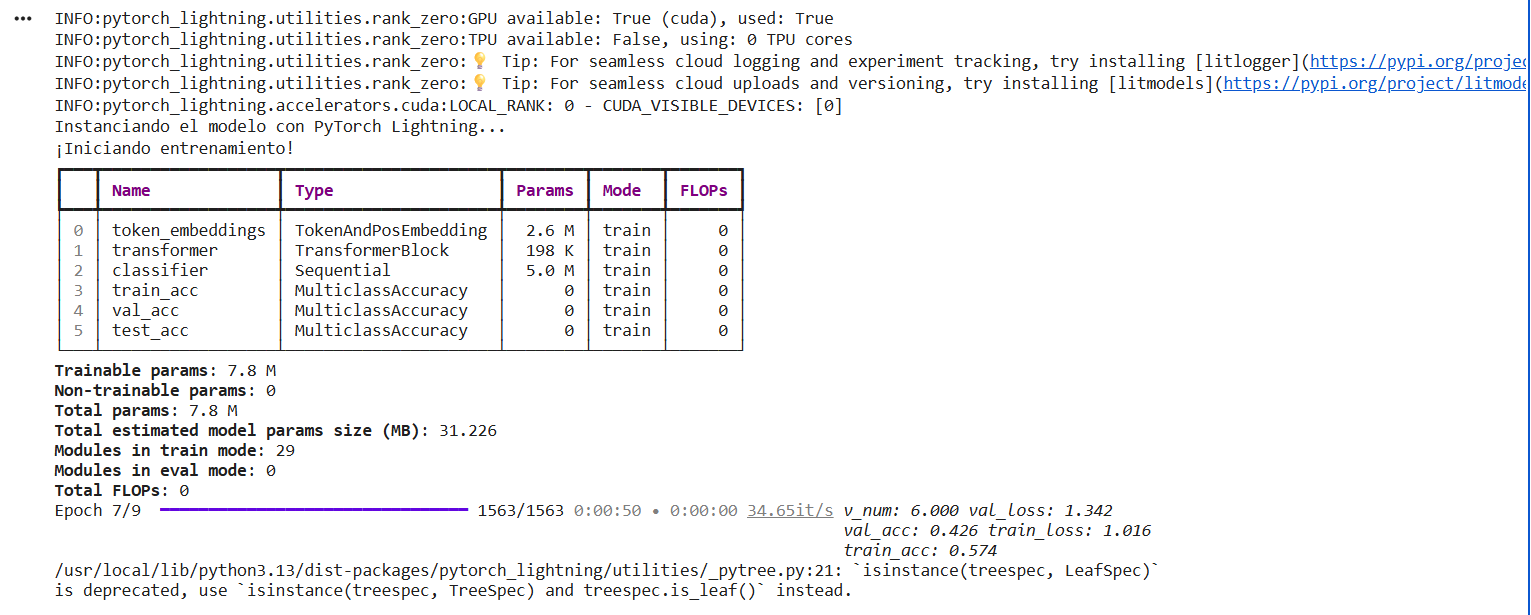



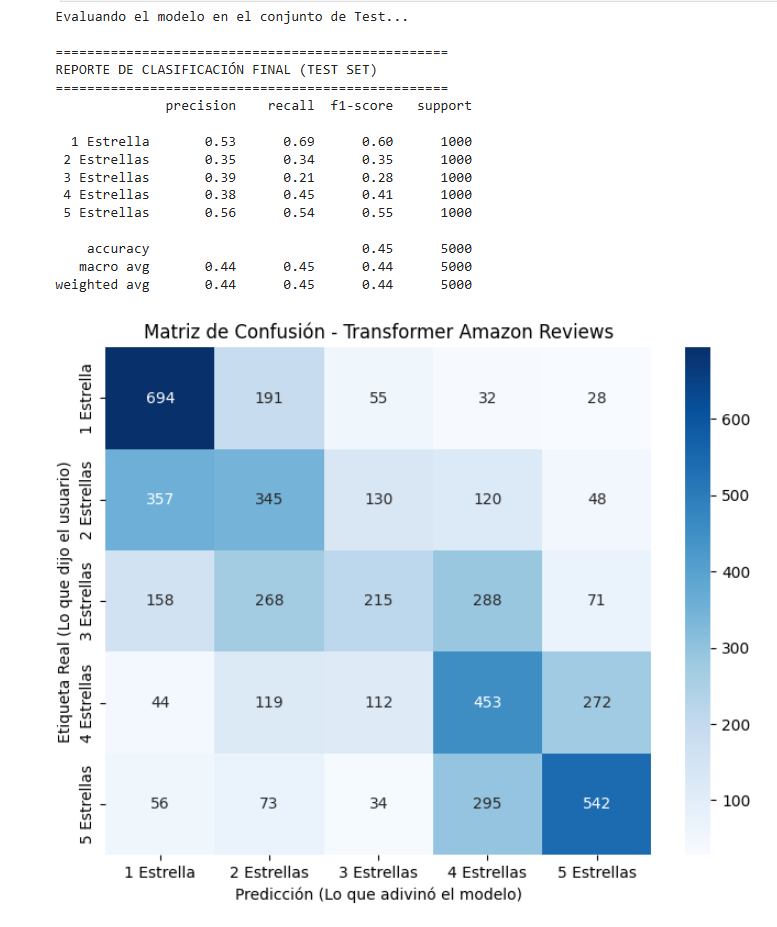

In [ ]:
# Hiperparámetros alineados con tu EDA previo
MAX_LEN = 75            # seq_length de tus DataLoaders
VOCAB_SIZE = 20000      # len(vocab)
NUM_CLASSES = 5         # Clases en Amazon Reviews
EMB_DIM = 128
NUM_HEADS = 4

print("Instanciando el modelo con PyTorch Lightning...")
model = AmazonReviewClassifier(
    max_len=MAX_LEN,
    vocab_size=VOCAB_SIZE,
    num_classes=NUM_CLASSES,
    emb_dim=EMB_DIM,
    num_heads=NUM_HEADS
)

# Callback para detener el entrenamiento si el modelo deja de aprender
callbacks = [EarlyStopping(monitor='val_loss', patience=3, mode='min')]
tb_logger = TensorBoardLogger('tb_logs', name='AmazonReviewClassifier')

# Configurar el Trainer (Acelerará automáticamente con GPU si está disponible)
trainer = Trainer(
    max_epochs=4, # máx. 4 épocas
    callbacks=callbacks,
    accelerator="auto",
    devices=1,
    logger=tb_logger
)

print("¡Iniciando entrenamiento!")
# Usamos los DataLoaders que ya construiste en las celdas previas
trainer.fit(model, train_dataloaders=train_loader, val_dataloaders=val_loader)

Instanciando el modelo con PyTorch Lightning...


INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


¡Iniciando entrenamiento!


┏━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name             ┃ Type                 ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ token_embeddings │ TokenAndPosEmbedding │  2.6 M │ train │     0 │
│ 1 │ transformer      │ TransformerBlock     │  198 K │ train │     0 │
│ 2 │ classifier       │ Sequential           │  5.0 M │ train │     0 │
│ 3 │ train_acc        │ MulticlassAccuracy   │      0 │ train │     0 │
│ 4 │ val_acc          │ MulticlassAccuracy   │      0 │ train │     0 │
│ 5 │ test_acc         │ MulticlassAccuracy   │      0 │ train │     0 │
└───┴──────────────────┴──────────────────────┴────────┴───────┴───────┘

Trainable params: 7.8 M                                                                                            
Non-trainable params: 0                                                                                            
Total params: 7.8 M                                                                                                
Total estimated model params size (MB): 31.226                                                                     
Modules in train mode: 29                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

/usr/local/lib/python3.13/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)`
is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=4` reached.


Evaluando el modelo en el conjunto de Test...

REPORTE DE CLASIFICACIÓN FINAL (TEST SET)
              precision    recall  f1-score   support

  1 Estrella       0.58      0.51      0.54      1000
 2 Estrellas       0.35      0.33      0.34      1000
 3 Estrellas       0.41      0.31      0.35      1000
 4 Estrellas       0.35      0.26      0.30      1000
 5 Estrellas       0.45      0.74      0.56      1000

    accuracy                           0.43      5000
   macro avg       0.43      0.43      0.42      5000
weighted avg       0.43      0.43      0.42      5000



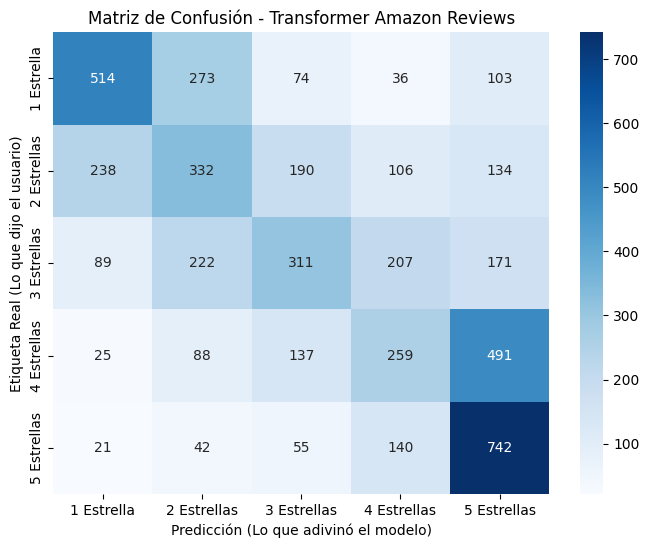

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import torch

# 1. Ponemos el modelo en modo evaluación (apaga Dropout, etc.)
model.eval()
#trainer.test(model, test_loader)

# Listas para almacenar predicciones y valores reales
y_verdaderos = []
y_predichos = []

print("Evaluando el modelo en el conjunto de Test...")

# 2. Desactivamos el cálculo de gradientes para ahorrar memoria
with torch.no_grad():
    for batch in test_loader:
        # Movemos los datos al mismo dispositivo que el modelo (GPU)
        x = batch['input_ids'].to(model.device)
        y = batch['label'].to(model.device)
        mask = (x != 0).long().to(model.device)

        # Hacemos la predicción
        y_hat = model(x, mask)
        preds = torch.argmax(y_hat, dim=1)

        # Movemos los resultados a la CPU y los agregamos a nuestras listas
        y_verdaderos.extend(y.cpu().numpy())
        y_predichos.extend(preds.cpu().numpy())

# 3. Reporte de Clasificación (Precision, Recall, F1-Score por clase)
nombres_clases = ['1 Estrella', '2 Estrellas', '3 Estrellas', '4 Estrellas', '5 Estrellas']

print("\n" + "="*50)
print("REPORTE DE CLASIFICACIÓN FINAL (TEST SET)")
print("="*50)
print(classification_report(y_verdaderos, y_predichos, target_names=nombres_clases))

# 4. Matriz de Confusión Visual
cm = confusion_matrix(y_verdaderos, y_predichos)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=nombres_clases, yticklabels=nombres_clases)
plt.title('Matriz de Confusión - Transformer Amazon Reviews')
plt.ylabel('Etiqueta Real (Lo que dijo el usuario)')
plt.xlabel('Predicción (Lo que adivinó el modelo)')
plt.show()

## Tokenizador gpt2

In [ ]:
from transformers import AutoTokenizer
from tokenizers.pre_tokenizers import ByteLevel
from tqdm.auto import tqdm

# 1. Cargar el tokenizador base de GPT-2
tokenizer_base = AutoTokenizer.from_pretrained("gpt2")
base_vocab = list(ByteLevel.alphabet())

# Se cambia LA_VARIABLE_REAL por la lista o columna de textos de entrenamiento
textos_para_entrenar = train_data['text']

# Si la variable es una columna de Pandas (Series), la convertimos a lista para evitar errores al iterar
if hasattr(textos_para_entrenar, 'tolist'):
    textos_para_entrenar = textos_para_entrenar.tolist()

# 2. Crear un iterador para tus textos
def batch_iterator(texts, batch_size=1000):
    for i in tqdm(range(0, len(texts), batch_size)):
        yield texts[i : i + batch_size]

# 3. Entrenar el nuevo tokenizador ajustado a tu corpus
amazon_tokenizer = tokenizer_base.train_new_from_iterator(
    batch_iterator(textos_para_entrenar),
    vocab_size=20000,
    initial_alphabet=base_vocab,
    show_progress=True,
    new_special_tokens=["[PAD]"]
)

# 4. Asegurar que el token de padding esté configurado
amazon_tokenizer.pad_token = "[PAD]"

  0%|          | 0/50 [00:00<?, ?it/s]

In [ ]:
import torch
from torch.utils.data import DataLoader

# 1. Obtenemos el ID que el tokenizador le asignó a [PAD]
pad_id = amazon_tokenizer.pad_token_id
print(f"El ID del token [PAD] en el nuevo tokenizador es: {pad_id}")

# 2. Función adaptadora para la clase Dataset actual
def hf_tokenize_text(text: str, max_length: int = 75):
    # El tokenizador de HF maneja el truncado y el padding automáticamente
    encoding = amazon_tokenizer(
        text,
        truncation=True,
        max_length=max_length,
        padding='max_length'
    )
    return encoding['input_ids']

print("\nEmpaquetando en nuevos DataLoaders con Tokenizador GPT-2...")
seq_length = 75
batch_size = 32 if torch.cuda.is_available() else 16

# 3. Instanciamos los Datasets usando la clase original pero con la nueva función
train_dataset_hf = AmazonReviewsDataset(train_data, hf_tokenize_text, seq_length)
val_dataset_hf = AmazonReviewsDataset(val_data, hf_tokenize_text, seq_length)
test_dataset_hf = AmazonReviewsDataset(test_data, hf_tokenize_text, seq_length)

# 4. Creamos los DataLoaders
train_loader_hf = DataLoader(train_dataset_hf, batch_size=batch_size, shuffle=True)
val_loader_hf = DataLoader(val_dataset_hf, batch_size=batch_size)
test_loader_hf = DataLoader(test_dataset_hf, batch_size=batch_size)

print(f"¡Nuevos DataLoaders listos! Lotes de entrenamiento: {len(train_loader_hf)}")

El ID del token [PAD] en el nuevo tokenizador es: 1

Empaquetando en nuevos DataLoaders con Tokenizador GPT-2...
¡Nuevos DataLoaders listos! Lotes de entrenamiento: 1563


In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader

# 1. Obtenemos el ID que el tokenizador le asignó a [PAD]
pad_id = amazon_tokenizer.pad_token_id
print(f"El ID del token [PAD] en el nuevo tokenizador es: {pad_id}")

# 2. Creamos una NUEVA clase Dataset exclusiva para HuggingFace
class AmazonReviewsDatasetHF(Dataset):
    def __init__(self, hf_dataset, tokenizer, max_length=75):
        self.dataset = hf_dataset
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        row = self.dataset[idx]

        # El tokenizador de HF hace el padding y truncamiento internamente
        encoding = self.tokenizer(
            str(row['text']),
            truncation=True,
            max_length=self.max_length,
            padding='max_length',
            return_tensors='pt'
        )

        return {
            'input_ids': encoding['input_ids'].flatten(),
            'label': torch.tensor(row['label'], dtype=torch.long)
        }

print("\nEmpaquetando en nuevos DataLoaders con Tokenizador GPT-2 (Contexto Ampliado)...")
seq_length = 75 # <-- CAMBIO CLAVE: Aumentamos el límite para GPT-2
batch_size = 32 if torch.cuda.is_available() else 16

# Instanciamos los Datasets usando la nueva longitud
train_dataset_hf = AmazonReviewsDatasetHF(train_data, amazon_tokenizer, seq_length)
val_dataset_hf = AmazonReviewsDatasetHF(val_data, amazon_tokenizer, seq_length)
test_dataset_hf = AmazonReviewsDatasetHF(test_data, amazon_tokenizer, seq_length)

# Creamos los DataLoaders
train_loader_hf = DataLoader(train_dataset_hf, batch_size=batch_size, shuffle=True)
val_loader_hf = DataLoader(val_dataset_hf, batch_size=batch_size)
test_loader_hf = DataLoader(test_dataset_hf, batch_size=batch_size)

print(f"¡Nuevos DataLoaders listos! Lotes de entrenamiento: {len(train_loader_hf)}")

El ID del token [PAD] en el nuevo tokenizador es: 1

Empaquetando en nuevos DataLoaders con Tokenizador GPT-2 (Contexto Ampliado)...
¡Nuevos DataLoaders listos! Lotes de entrenamiento: 1563


In [ ]:
import torch.nn.functional as F
from pytorch_lightning import Trainer
from pytorch_lightning.callbacks.early_stopping import EarlyStopping

# 1. Redefinimos la clase para que herede de la ÚLTIMA versión de AmazonReviewClassifier (la de 3 capas)
class AmazonReviewClassifierHF(AmazonReviewClassifier):
    def __init__(self, pad_token_id, **kwargs):
        super().__init__(**kwargs)
        self.pad_token_id = pad_token_id

    def training_step(self, batch, batch_idx):
        x = batch['input_ids']
        y = batch['label']
        mask = (x != self.pad_token_id).long()
        y_hat = self(x, mask)
        loss = F.cross_entropy(y_hat, y)
        self.train_acc(y_hat, y)
        self.log('train_loss', loss, prog_bar=True, on_step=False, on_epoch=True)
        self.log('train_acc', self.train_acc, prog_bar=True, on_step=False, on_epoch=True)
        return loss

    def validation_step(self, batch, batch_idx):
        x = batch['input_ids']
        y = batch['label']
        mask = (x != self.pad_token_id).long()
        y_hat = self(x, mask)
        loss = F.cross_entropy(y_hat, y)
        self.val_acc(y_hat, y)
        self.log('val_loss', loss, prog_bar=True, on_step=False, on_epoch=True)
        self.log('val_acc', self.val_acc, prog_bar=True, on_step=False, on_epoch=True)
        return loss

    def test_step(self, batch, batch_idx):
        x = batch['input_ids']
        y = batch['label']
        mask = (x != self.pad_token_id).long()
        y_hat = self(x, mask)
        self.test_acc(y_hat, y)
        self.log('test_acc', self.test_acc, prog_bar=True, on_step=False, on_epoch=True)


print("Instanciando el nuevo modelo con GPT-2 Tokenizer...")
# 2. Instanciamos con los hiperparámetros óptimos que encontramos en el EDA
model_hf = AmazonReviewClassifierHF(
    pad_token_id=pad_id,
    max_len=75,
    vocab_size=20000,
    num_classes=5,
    emb_dim=128,      # Mantenemos el aumento a 128 para que sean comparables los resultados
    num_heads=4,      # Mantenemos las 4 cabezas para que sean comparables los resultados
    num_layers=3      # Mantenemos la profundidad de 3 bloques para que sean comparables los resultados
)

callbacks_hf = [EarlyStopping(monitor='val_loss', patience=3, mode='min')]

trainer_hf = Trainer(
    max_epochs=4,
    callbacks=callbacks_hf,
    accelerator="auto",
    devices=1
)

print("¡Iniciando entrenamiento con BPE (GPT-2)!")
trainer_hf.fit(model_hf, train_dataloaders=train_loader_hf, val_dataloaders=val_loader_hf)

Instanciando el nuevo modelo con GPT-2 Tokenizer...


INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


¡Iniciando entrenamiento con BPE (GPT-2)!


INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name             ┃ Type                 ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ token_embeddings │ TokenAndPosEmbedding │  2.6 M │ train │     0 │
│ 1 │ transformer      │ TransformerBlock     │  198 K │ train │     0 │
│ 2 │ classifier       │ Sequential           │  5.0 M │ train │     0 │
│ 3 │ train_acc        │ MulticlassAccuracy   │      0 │ train │     0 │
│ 4 │ val_acc          │ MulticlassAccuracy   │      0 │ train │     0 │
│ 5 │ test_acc         │ MulticlassAccuracy   │      0 │ train │     0 │
└───┴──────────────────┴──────────────────────┴────────┴───────┴───────┘

Trainable params: 7.8 M                                                                                            
Non-trainable params: 0                                                                                            
Total params: 7.8 M                                                                                                
Total estimated model params size (MB): 31.226                                                                     
Modules in train mode: 29                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

/usr/local/lib/python3.13/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)`
is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=4` reached.


Evaluando el modelo GPT-2 en el conjunto de Test...

REPORTE DE CLASIFICACIÓN FINAL (GPT-2 BPE)
              precision    recall  f1-score   support

  1 Estrella       0.47      0.67      0.55      1000
 2 Estrellas       0.37      0.19      0.25      1000
 3 Estrellas       0.36      0.32      0.34      1000
 4 Estrellas       0.33      0.39      0.36      1000
 5 Estrellas       0.50      0.51      0.51      1000

    accuracy                           0.41      5000
   macro avg       0.41      0.41      0.40      5000
weighted avg       0.41      0.41      0.40      5000



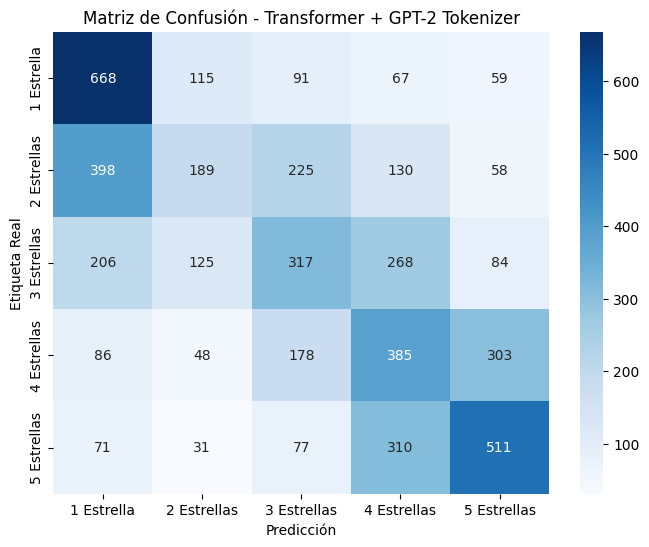

In [ ]:
# 1. Ponemos el modelo de GPT-2 en modo evaluación
model_hf.eval()

y_verdaderos_hf = []
y_predichos_hf = []

print("Evaluando el modelo GPT-2 en el conjunto de Test...")

# 2. Desactivamos gradientes
with torch.no_grad():
    for batch in test_loader_hf:
        x = batch['input_ids'].to(model_hf.device)
        y = batch['label'].to(model_hf.device)

        # Máscara usando el pad_id del tokenizador de GPT-2
        mask = (x != pad_id).long().to(model_hf.device)

        y_hat = model_hf(x, mask)
        preds = torch.argmax(y_hat, dim=1)

        y_verdaderos_hf.extend(y.cpu().numpy())
        y_predichos_hf.extend(preds.cpu().numpy())

# 3. Reporte y Matriz
print("\n" + "="*50)
print("REPORTE DE CLASIFICACIÓN FINAL (GPT-2 BPE)")
print("="*50)
print(classification_report(y_verdaderos_hf, y_predichos_hf, target_names=nombres_clases))

cm_hf = confusion_matrix(y_verdaderos_hf, y_predichos_hf)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_hf, annot=True, fmt='d', cmap='Blues',
            xticklabels=nombres_clases, yticklabels=nombres_clases)
plt.title('Matriz de Confusión - Transformer + GPT-2 Tokenizer')
plt.ylabel('Etiqueta Real')
plt.xlabel('Predicción')
plt.show()

# **Conclusiones**

_(Completar con los resultados obtenidos. Puntos de partida:_

- Comparamos el **mismo problema del Taller 1** (satisfacción en e-commerce, 5 clases, mismos datos y splits) resuelto ahora con un **Transformer construido desde cero**: tokenizador BPE propio, positional embeddings, multi-head attention, bloques encoder con conexiones residuales y agregación por mean pooling.
- El diseño con *mean pooling* con máscara redujo el tamaño del modelo en **más de un orden de magnitud** respecto al enfoque `Flatten` del notebook guía (~9M vs ~140M parámetros), sin sacrificar capacidad de clasificación.
- Las máscaras de atención resuelven de forma elegante el problema del padding que en el Taller 1 requirió `padding_idx` y `pack_padded_sequence`: el padding simplemente no participa en la atención ni en la agregación.
- La tokenización BPE elimina el problema de los tokens desconocidos (`[UNK]`) del vocabulario word-level del Taller 1 y es robusta a errores ortográficos frecuentes en reseñas reales.
- El Transformer requiere más recursos por época (atención cuadrática), pero con textos cortos el costo es bajo y el entrenamiento es paralelizable a diferencia de la LSTM.)

- La configuración con tokenización BPE entrenada a partir del tokenizador de GPT-2 presentó un desempeño global inferior en la ejecución registrada: la exactitud pasó de aproximadamente 43 % a 41 % y el F1 macro disminuyó de 0,42 a 0,40. Aunque el F1 mejoró para las categorías de una y cuatro estrellas, estas ganancias no compensaron las reducciones en las demás clases, especialmente en dos estrellas, donde pasó de 0,34 a 0,25. Los resultados no evidencian una ventaja de BPE bajo las condiciones evaluadas; sin embargo, sería necesario repetir el experimento con varias semillas para determinar si la diferencia es consistente. Además, utilizar el mismo límite de 75 tokens no garantiza conservar la misma cantidad de texto con ambos tokenizadores.

- La arquitectura mantiene una oportunidad concreta de optimización: el clasificador basado en Flatten y capas densas concentra aproximadamente 5 millones de los 7,8 millones de parámetros totales, y su tamaño depende de la longitud de entrada. Aunque la máscara impide atender a las posiciones de relleno como claves, no elimina las representaciones generadas en esas posiciones antes de pasarlas al clasificador. Evaluar una agregación mediante promedio enmascarado permitiría excluirlas y reducir considerablemente los parámetros de la cabeza de clasificación. La reducción de tamaño se deriva del diseño, mientras que cualquier mejora en desempeño debe comprobarse experimentalmente.

## **Líneas de Trabajo Futuro**

- **Fine-tuning de un modelo pre-entrenado** (BERT en español: `dccuchile/bert-base-spanish-wwm-cased`): los transformers desde cero con 50k ejemplos tienen un techo; el modelo pre-entrenado ya "sabe" el idioma y solo se adapta a la tarea (tema de las próximas sesiones).
- **Clasificación jerárquica o ordinal:** las 5 estrellas son un problema *ordinal*; una pérdida ordinal (por ejemplo, regresión sobre el número de estrellas o penalizar más la confusión de extremos) podría mejorar las matrices de confusión.
- **Análisis de atención:** extraer los `attention` de los casos mal clasificados para ver a qué palabras presta atención el modelo (interpretabilidad).
- **Augmentación de datos** con reseñas paráfraseadas o back-translation para las clases intermedias.
- **Combinação de modelos:** ensamble LSTM + Transformer promediando probabilidades.